# MLP simples com a diferença


- 1 saida - DeltaTheta
- 2 entradas - Vd e Ve
- 1 camada
- 1 neurônio


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = "VD-VE"   
TARGET = "Theta"       

for i in range(4):   
    Dataset = pd.read_csv(f"../Dados/Data{i + 1}.csv")
    
    # Remove colunas desnecessárias
    Dataset = Dataset.drop(columns=["X", "Y", "Setpoint VD", "Setpoint VE", "tempo"])
    
    # Ajusta índice pelo tempo
    Dataset.index = (np.arange(0, len(Dataset), 1).astype(float) * 0.07).round(5)
    
    # Cria nova coluna com VD - VE
    Dataset[PREDICTORS] = Dataset["VD"] - Dataset["VE"]
    
    Datasets.append(Dataset)
    
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head(5))


++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
      Theta    VD    VE  VD-VE
0.00    0.0  0.00  0.00    0.0
0.07    0.0  2.33  2.33    0.0
0.14    0.0  2.33  2.33    0.0
0.21    0.0  2.33  2.33    0.0
0.28    0.0  2.33  2.33    0.0
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
      Theta    VD    VE  VD-VE
0.00    0.0  2.33  2.33    0.0
0.07    0.0  2.33  2.33    0.0
0.14    0.0  2.33  2.33    0.0
0.21    0.0  2.33  2.33    0.0
0.28   -0.0  2.33  2.33    0.0
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
      Theta    VD    VE  VD-VE
0.00    0.0  0.00  0.00    0.0
0.07    0.0  2.33  2.33    0.0
0.14    0.0  2.33  2.33    0.0
0.21    0.0  2.33  2.33    0.0
0.28    0.0  2.33  2.33    0.0
++++++++++++++++++++ Dataset 4 +++++++++++++++++++++++
      Theta    VD    VE  VD-VE
0.00    0.0  2.33  2.33    0.0
0.07    0.0  2.33  2.33    0.0
0.14    0.0  2.33  2.33    0.0
0.21    0.0  2.33  2.33    0.0
0.28    0.0  2.33  2.33    0.0


In [2]:
for  i in range(4):
    Dataset = Datasets[i].copy()  # evita sobrescrever o original
    Dataset["DeltaTheta"] = Dataset[TARGET].shift(-1) - Dataset[TARGET]
    # ou equivalente: Dataset["DeltaTheta"] = Dataset[TARGET].diff().shift(-1)
    
    # remove o último NaN (último ponto não tem próximo valor)
    Dataset = Dataset.dropna(subset=["DeltaTheta"])
    Datasets[i] = Dataset
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Datasets[i].tail(5))


++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        Theta    VD    VE  VD-VE  DeltaTheta
149.80  -0.81 -2.20 -2.38   0.18        0.00
149.87  -0.81 -2.23 -2.40   0.17        0.01
149.94  -0.80 -2.41 -2.24  -0.17        0.00
150.01  -0.80 -2.40 -2.22  -0.18        0.00
150.08  -0.80 -2.40 -2.22  -0.18        0.00
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        Theta    VD    VE  VD-VE  DeltaTheta
141.47   0.73 -2.22 -2.40   0.18        0.00
141.54   0.73 -2.23 -2.40   0.17        0.00
141.61   0.73 -2.23 -2.40   0.17        0.01
141.68   0.74 -2.24 -2.41   0.17        0.00
141.75   0.74 -2.41 -2.25  -0.16        0.00
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
       Theta    VD    VE  VD-VE  DeltaTheta
92.40  -0.81 -2.36 -2.18  -0.18        0.00
92.47  -0.81 -2.37 -2.19  -0.18        0.00
92.54  -0.81 -2.37 -2.19  -0.18       -0.01
92.61  -0.82 -2.37 -2.18  -0.19       -0.01
92.68  -0.83 -2.38 -2.20  -0.18       -0.01
++++++++++++++++++++ Dataset 4 

In [3]:
NormDatasets = []

PREDICTORS = ["VD-VE" ]  
TARGET = ["DeltaTheta"]
SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = Datasets[0]
TrainDataset[PREDICTORS] = SCALER.fit_transform(TrainDataset[PREDICTORS])
TrainDataset[TARGET] = OUT_SCALER.fit_transform(TrainDataset[TARGET])
NormDatasets.append(TrainDataset)

for i in range(3):
      CurrentTestDataset = Datasets[i + 1]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)
      print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
      print(NormDatasets[i].head(5))

++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
      Theta    VD    VE     VD-VE  DeltaTheta
0.00    0.0  0.00  0.00  0.038989    0.035731
0.07    0.0  2.33  2.33  0.038989    0.035731
0.14    0.0  2.33  2.33  0.038989    0.035731
0.21    0.0  2.33  2.33  0.038989    0.035731
0.28    0.0  2.33  2.33  0.038989    0.035731
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
      Theta    VD    VE     VD-VE  DeltaTheta
0.00    0.0  2.33  2.33  0.038989    0.035731
0.07    0.0  2.33  2.33  0.038989    0.035731
0.14    0.0  2.33  2.33  0.038989    0.035731
0.21    0.0  2.33  2.33  0.038989    0.035731
0.28   -0.0  2.33  2.33  0.038989    0.035731
++++++++++++++++++++ Dataset Normalizado 3 +++++++++++++++++++++++
      Theta    VD    VE     VD-VE  DeltaTheta
0.00    0.0  0.00  0.00  0.038989    0.035731
0.07    0.0  2.33  2.33  0.038989    0.035731
0.14    0.0  2.33  2.33  0.038989    0.035731
0.21    0.0  2.33  2.33  0.038989    0.035731
0.28    0.0  2.33

In [4]:
x_train = np.array(TrainDataset[PREDICTORS])
y_train = np.array(TrainDataset[TARGET])

x_val = np.array((NormDatasets[1])[PREDICTORS])
y_val = np.array((NormDatasets[1])[TARGET])

print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

Dimensão da entrada: (2145, 1)
Dimensão da saida: (2145, 1)


In [5]:
import matplotlib.pyplot as plt

def PlotHistory(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def PlotOut(axs, title, y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    axs.scatter(time, y_true, marker='o', label='Amostras Reais')
    axs.scatter(time, y_pred, marker='x', label='Valores Preditos')
    axs.set_title(f'{title}')
    axs.set_xlabel('Theta')
    axs.set_ylabel('tempo')
    axs.legend()
    axs.grid(True)

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

TITLES = ["Training", "Validation", "Test 1", "Test 2"]

def EvalModel(model):
    fig, axs = plt.subplots(4, 1, figsize=(12, 12))
    for i, dataset in enumerate(NormDatasets):
        x = np.array(dataset[PREDICTORS])
        
        # diferenças reais e previstas (já desnormalizadas)
        y_diff = OUT_SCALER.inverse_transform(dataset[TARGET])
        y_pred_diff = OUT_SCALER.inverse_transform(model.predict(x))
        
        # valor inicial de theta no dataset original (não normalizado)
        theta0 = Datasets[i]["Theta"].iloc[0]  
        
        # reconstrução: soma cumulativa
        y_real = theta0 + np.cumsum(y_diff, axis=0)
        y_pred = theta0 + np.cumsum(y_pred_diff, axis=0)
        
        # métricas no espaço de θ
        R2 = r2_score(y_real, y_pred)
        MSE = mean_squared_error(y_real, y_pred)
        print(f"R²_{TITLES[i]} = {R2}")
        print(f"MSE_{TITLES[i]} = {MSE}")
        
        # plota saída
        PlotOut(axs[i], TITLES[i], y_real, y_pred)


In [7]:
from tensorflow import keras
from keras.callbacks import EarlyStopping

INPUT_SIZE = len(PREDICTORS)  

model = keras.models.Sequential([
    keras.layers.Input(shape=(INPUT_SIZE,)),
    keras.layers.Dense(1, activation="linear"),  
])
model.summary()
print(f"Pesos inciais:\n {model.get_weights()}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Pesos inciais:
 [array([[1.6489397]], dtype=float32), array([0.], dtype=float32)]


Configures the model for training.

In [8]:
model.compile(loss="mean_squared_error", optimizer="adam")

Trains the model for a fixed number of epochs (dataset iterations).

In [9]:
early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                patience=50,
                                restore_best_weights=True)

history = model.fit(x_train, 
                    y_train, 
                    epochs=1000,
                    callbacks=[early_stopping_monitor],
 validation_data=(x_val, y_val))

Epoch 1/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.9275 - val_loss: 1.9388
Epoch 2/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8062 - val_loss: 1.8340
Epoch 3/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5981 - val_loss: 1.7388
Epoch 4/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3914 - val_loss: 1.6493
Epoch 5/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2125 - val_loss: 1.5643
Epoch 6/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1230 - val_loss: 1.4918
Epoch 7/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9837 - val_loss: 1.4192
Epoch 8/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2000 - val_loss: 1.3588
Epoch 9/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8787 - val_loss: 1.2985
Epoch 10/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7470 - val_loss: 1.2487
Epoch 11/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6150 - val_loss: 1.2013
Epoch 12/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [10]:
print(f"Pesos finais:\n {model.get_weights()}")

Pesos finais:
 [array([[0.28155664]], dtype=float32), array([-0.00203968], dtype=float32)]


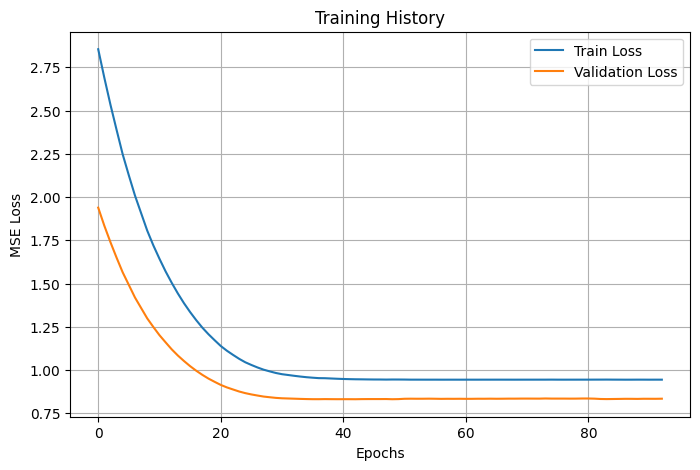

In [11]:
PlotHistory(history)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
R²_Training = 0.478180906393665
MSE_Training = 0.22865697923946704
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step
R²_Validation = 0.4779082217979727
MSE_Validation = 0.2283962684621003
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R²_Test 1 = 0.37247062984821155
MSE_Test 1 = 0.1387343700995234
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R²_Test 2 = 0.4453015616343569
MSE_Test 2 = 0.19829348079399697


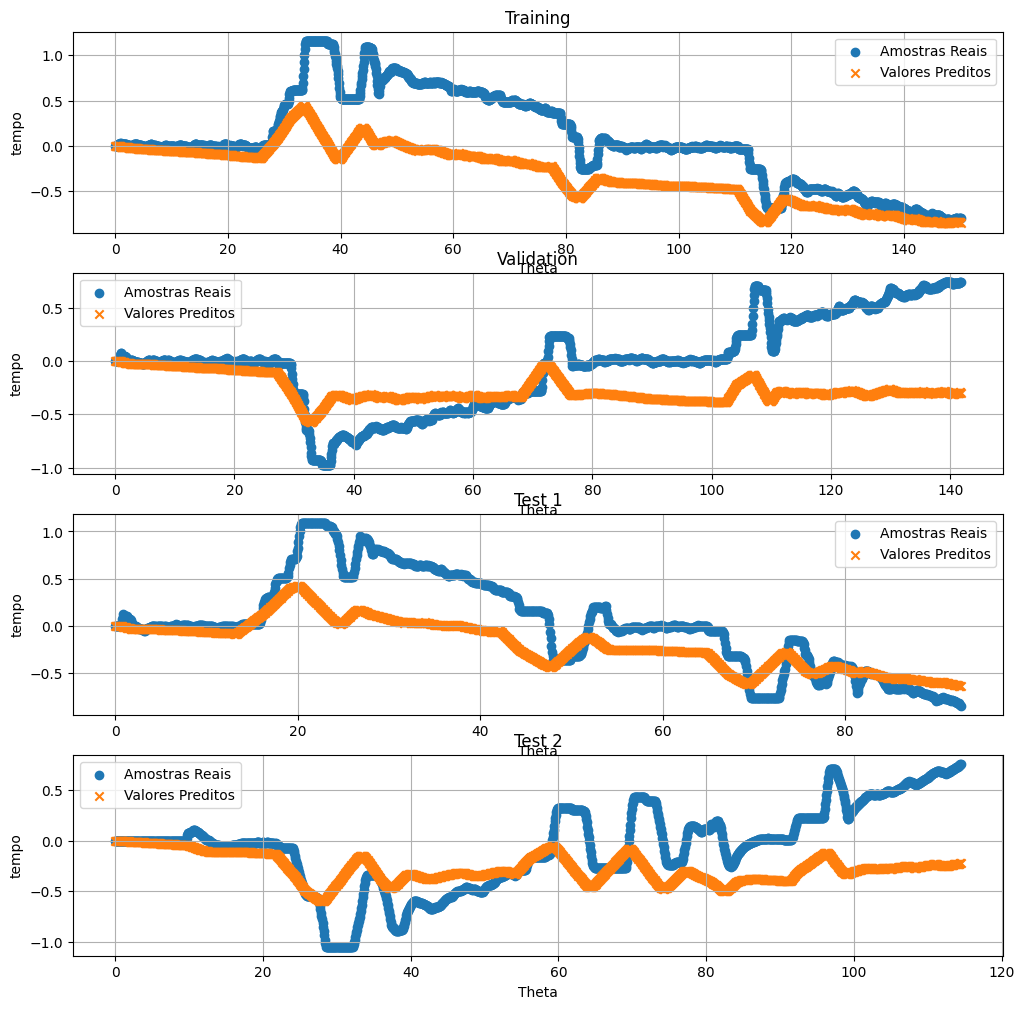

In [12]:
EvalModel(model)